In [16]:
# autoreload 
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from co60.loaders import load_run_configs
from co60.bin import establish_binning 
from co60.calibration import establish_gaussian_calibration_co60, copy_calibration
from co60.count import collect_coincidence_counts, collect_single_trigger_counts

In [18]:
RUN_CONFIGS_COINC_19May2026 = load_run_configs(cache_key="coincidence_trial_19May2026_load_run")

CH1_TRIGGER_RUN_CONFIGS_19May2026 = load_run_configs(cache_key="CH1_trig_trial_19May2026_load_run_single_trigger")

CH2_TRIGGER_RUN_CONFIGS_19May2026 = load_run_configs(cache_key="CH2_trig_trial_19May2026_load_run_single_trigger")

[loaders] Cache hit — loading 'coincidence_trial_19May2026_load_run' from C:\Users\pomar\OneDrive\Desktop\Javier_Ang_Corr_Project\co60_angular_correlation\cache\coincidence_trial_19May2026_load_run.pkl
[loaders] Cache hit — loading 'CH1_trig_trial_19May2026_load_run_single_trigger' from C:\Users\pomar\OneDrive\Desktop\Javier_Ang_Corr_Project\co60_angular_correlation\cache\CH1_trig_trial_19May2026_load_run_single_trigger.pkl
[loaders] Cache hit — loading 'CH2_trig_trial_19May2026_load_run_single_trigger' from C:\Users\pomar\OneDrive\Desktop\Javier_Ang_Corr_Project\co60_angular_correlation\cache\CH2_trig_trial_19May2026_load_run_single_trigger.pkl


In [19]:
RUN_CONFIGS_COINC_19May2026_BINNED = establish_binning(RUN_CONFIGS_COINC_19May2026)

In [20]:
display(RUN_CONFIGS_COINC_19May2026_BINNED)

[{'fname': 'C:\\Users\\pomar\\OneDrive\\Desktop\\Javier_Ang_Corr_Project\\5-19-2026/coincidence/co60_coincidence_trial_CH1_HV0_300+020_CH2+HV1_437+290_90deg_source_25cm_away_19May2026.dat',
  'angle': 90.0,
  'loaded_run': RunData(angle_deg=90.0, fname='C:\\Users\\pomar\\OneDrive\\Desktop\\Javier_Ang_Corr_Project\\5-19-2026/coincidence/co60_coincidence_trial_CH1_HV0_300+020_CH2+HV1_437+290_90deg_source_25cm_away_19May2026.dat', board_id=3067, channels={1: ChannelEvents(energy=array([ 40.84322715,  29.51233564, 115.71625098, ..., 111.53218546,
          30.6767083 ,  34.06983387]), pedestal=array([-0.00355405, -0.00407846, -0.00376176, ..., -0.00376332,
         -0.00471029, -0.00347963]), tthresh=array([161.32166748, 158.83156778, 180.24238633, ..., 181.4889621 ,
         122.21919997, 159.56642008])), 2: ChannelEvents(energy=array([ 67.7163662 ,  83.2463544 ,  68.44492947, ..., 126.76650876,
          72.4695064 ,  90.28327226]), pedestal=array([-0.00409652, -0.00401462, -0.00370975, 

In [21]:
RUN_CONFIGS_COINC_19May2026_CALIB = establish_gaussian_calibration_co60(RUN_CONFIGS_COINC_19May2026_BINNED)

C:\Users\pomar\OneDrive\Desktop\Javier_Ang_Corr_Project\co60_angular_correlation\src\co60\calibration.py:121: OptimizeWarning: Covariance of the parameters could not be estimated
  (m, b), _ = curve_fit(line, uncalib_centers, TRUE_ENERGIES)


The following is a fragile part of the pipeline, it requires someone to manually determine the Co-60 tolerances which best cover the Co-60 peaks, and pass this in as an argument to the function of co60.calibration.

This is done here with dict `co60_tols`.

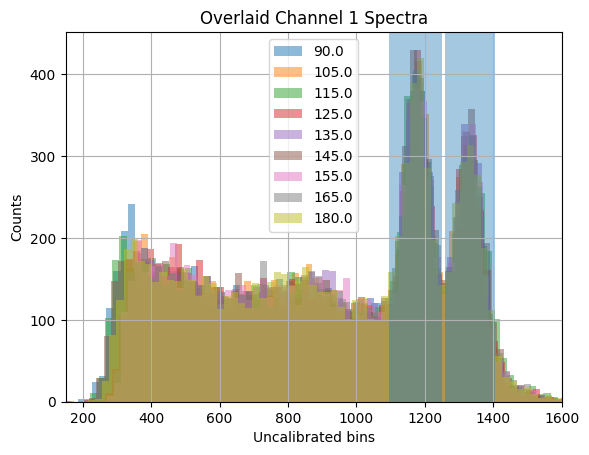

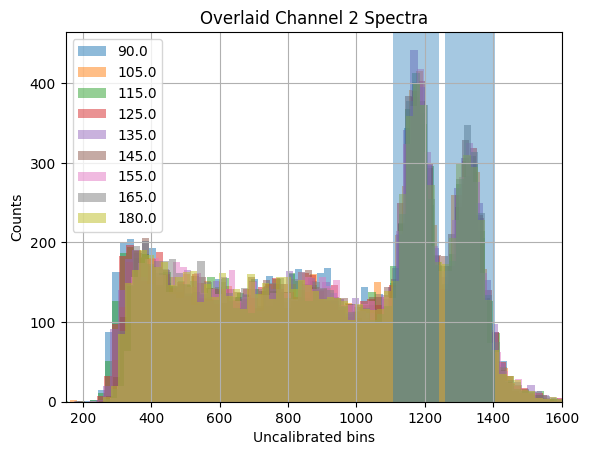

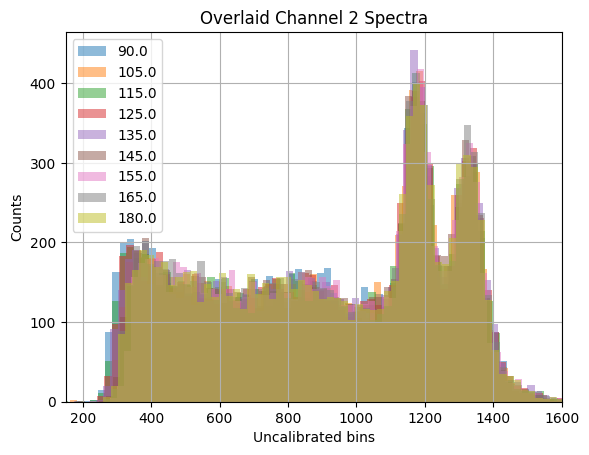

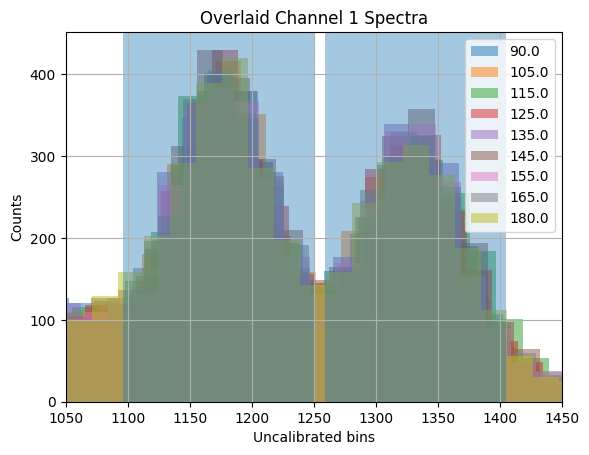

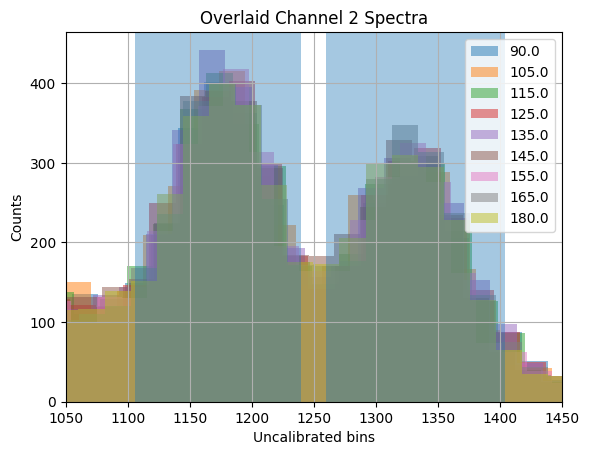

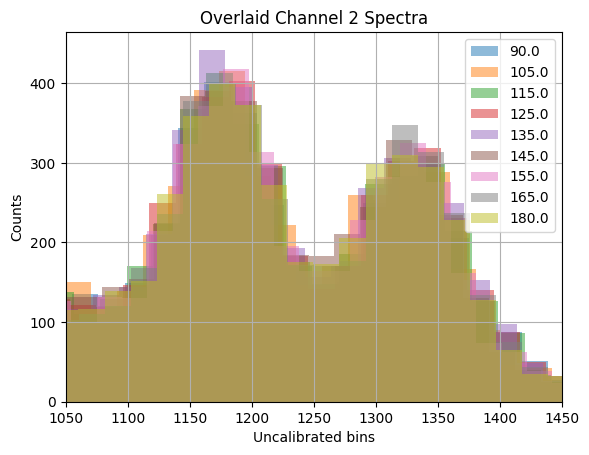

In [22]:
def plot_all_runs_with_gates(run_configs, key, xlim_left=None, xlim_right=None):
    num_channels = len(run_configs[0]['loaded_run'].channels)

    for chan_num in range(num_channels):
        chan_num = chan_num+1
        for run in run_configs:
            angle = run['angle']
            binned_counts = run[chan_num]['binned_counts']
            edges = run[chan_num][key]
            # plot
            plt.stairs(binned_counts, edges, alpha=0.5, label=f'{angle}', fill=True)

        plt.title(f'Overlaid Channel {chan_num} Spectra')
        plt.grid(True)
        plt.legend()
        plt.ylabel('Counts')
        plt.xlabel('Uncalibrated bins')

        if chan_num == 1:
            plt.axvspan(1096, 1250, alpha=0.4)
            plt.axvspan(1259, 1405, alpha=0.4)

            # plt.axvspan(1105, 1250, alpha=0.4)
            # plt.axvspan(1260, 1395, alpha=0.4)

        else:
            plt.axvspan(1106, 1240, alpha=0.4)
            plt.axvspan(1260, 1404, alpha=0.4)

            # plt.axvspan(1110, 1240, alpha=0.4)
            # plt.axvspan(1260, 1390, alpha=0.4)

        plt.xlim(xlim_left, xlim_right)
        plt.show()
        plt.close()

    for run in run_configs:
        angle = run['angle']
        binned_counts = run[chan_num]['binned_counts']
        edges = run[chan_num][key]
        # plot
        plt.stairs(binned_counts, edges, alpha=0.5, label=f'{angle}', fill=True)

    plt.title(f'Overlaid Channel {chan_num} Spectra')
    plt.grid(True)
    plt.legend()
    plt.ylabel('Counts')
    plt.xlabel('Uncalibrated bins')
    
    plt.xlim(xlim_left, xlim_right)

    plt.show()
    plt.close()

plot_all_runs_with_gates(RUN_CONFIGS_COINC_19May2026_CALIB, key='calib_edges', xlim_left=150, xlim_right=1600)
plot_all_runs_with_gates(RUN_CONFIGS_COINC_19May2026_CALIB, key='calib_edges', xlim_left=1050, xlim_right=1450)

# CHAN_1_TOL_1173 = 77
# CHAN_1_TOL_1332 = 73

# CHAN_2_TOL_1173 = 67
# CHAN_2_TOL_1332 = 72 

In [23]:
co60_tols = { 
1: dict(tol_1173=77, tol_1332=73), # in eV
2: dict(tol_1173=67, tol_1332=72)  # in eV
}

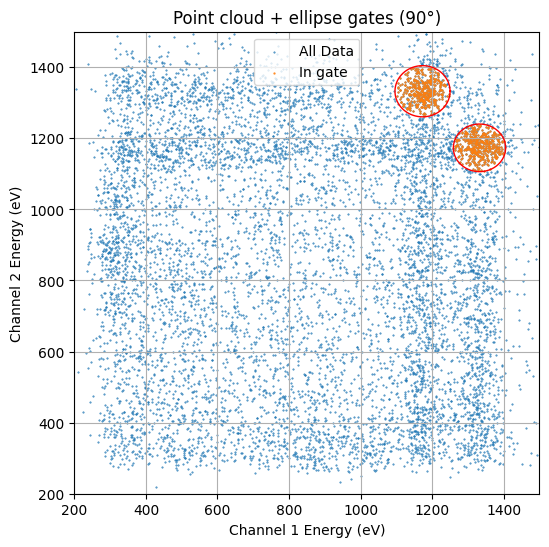

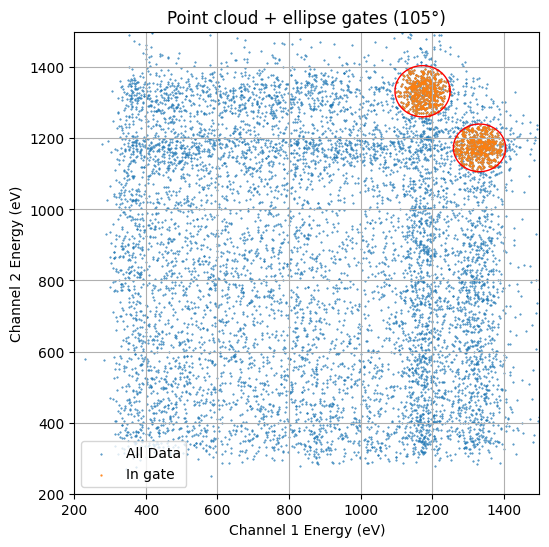

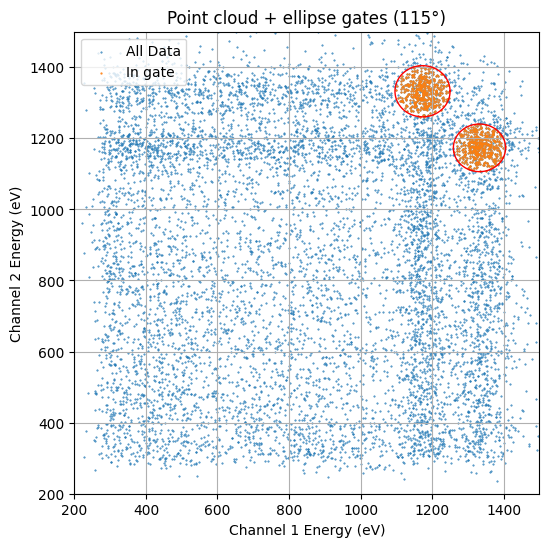

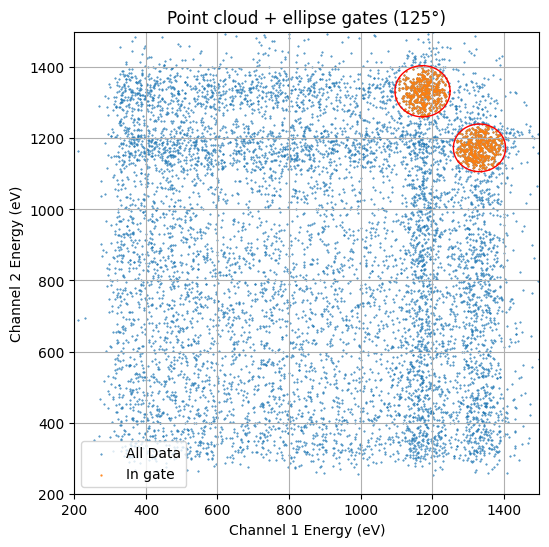

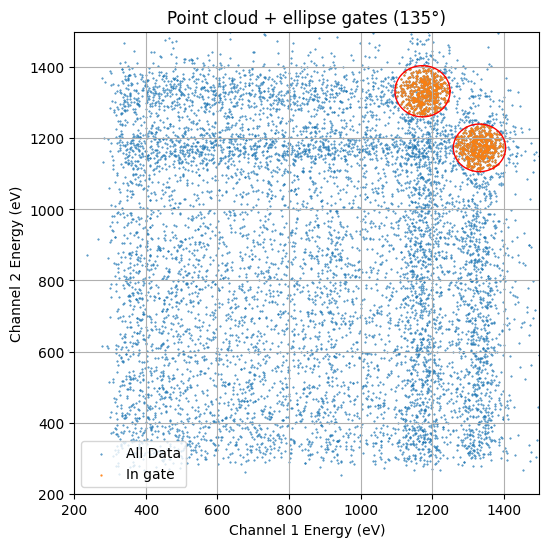

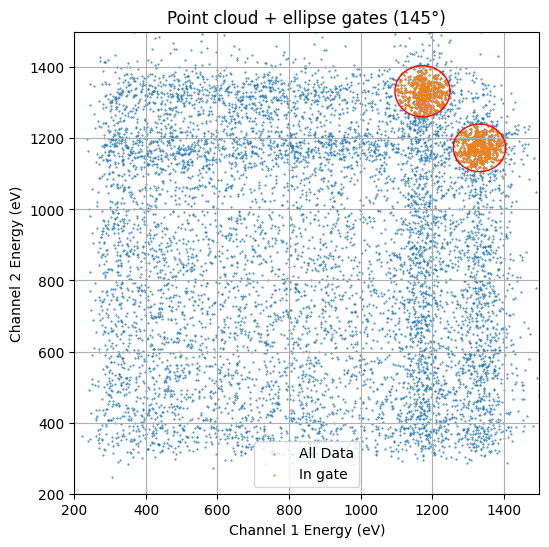

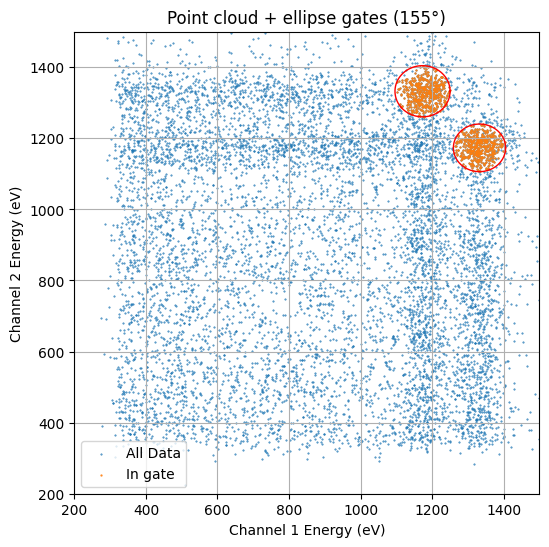

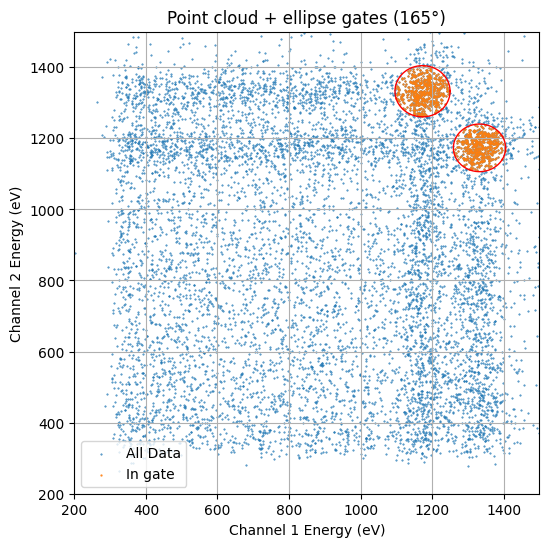

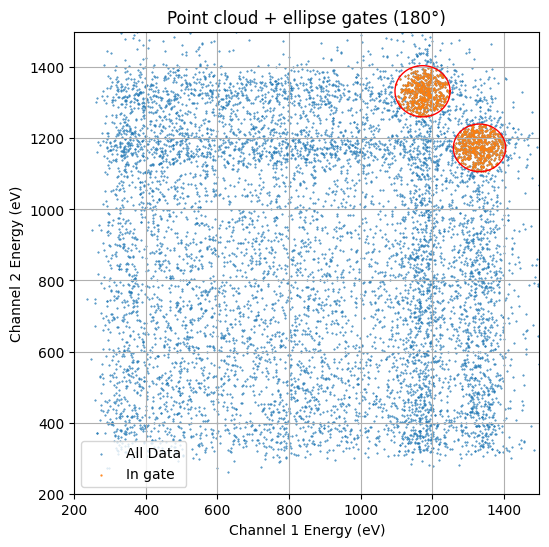

,N,N_unc,W,W_unc
angle,,,,
90.0,816,28.565714,1.000000,0.000000
105.0,966,31.080541,1.183824,0.056287
115.0,882,29.698485,1.080882,0.052501
125.0,903,30.049958,1.106618,0.053450
135.0,944,30.724583,1.156863,0.055298
145.0,1008,31.749016,1.235294,0.058171
155.0,935,30.577770,1.145833,0.054893
165.0,981,31.320920,1.202206,0.056960
180.0,964,31.048349,1.181373,0.056197


In [24]:

def trace_ellipse(
    mu1: float, 
    mu2: float, 
    a: float, 
    b: float, 
    *, 
    theta_rad: float = 0.0,
    n_points: int = 300, 
    color="red", 
    lw=2, 
    label=None
) -> None:

    """
    Plot an ellipse boundary in (E1,E2) eV space. Purely a visualization tool.

    mu1, mu2 : center (eV)
    a, b     : full-length of semi-axes (eV) 
    theta_rad: rotation angle in radians
    """

    t = np.linspace(0, 2*np.pi, n_points)

    # Parametric ellipse before rotation
    xp = a * np.cos(t)
    yp = b * np.sin(t)

    if theta_rad != 0.0:
        c = np.cos(theta_rad)
        s = np.sin(theta_rad)
        x =  c*xp - s*yp
        y =  s*xp + c*yp
    else:
        x, y = xp, yp

    E1 = mu1 + x
    E2 = mu2 + y

    plt.plot(E1, E2, color=color, lw=lw, label=label)

def my_debug_plot(run, res):
    angle = run["angle"]
    plt.figure(figsize=(6, 6))
    plt.scatter(res["E1_eV"], res["E2_eV"], s=0.2, alpha=1, label="All Data")
    plt.scatter(res["E1_gate_eV"], res["E2_gate_eV"], s=0.4, alpha=0.9, label="In gate")
    for p in res["ellipse_params_list"]:
        trace_ellipse(*p, theta_rad=0.0, lw=1)
    plt.title(f"Point cloud + ellipse gates ({angle:.0f}°)")
    plt.xlabel('Channel 1 Energy (eV)')
    plt.ylabel('Channel 2 Energy (eV)')
    plt.xlim(200, 1500)
    plt.ylim(200, 1500)
    plt.grid(True)
    plt.legend()
    plt.show()
    plt.close()

df = collect_coincidence_counts(
    RUN_CONFIGS_COINC_19May2026_CALIB,
    co60_tols=co60_tols,
    norm_angle=90.0,
    debug_plot_fn=my_debug_plot,
)

display(df)

In [25]:
def co60_angular_correlation(theta_deg: np.ndarray) -> np.ndarray:
    """Theoretical Co-60 angular correlation function W(theta)."""
    theta = np.deg2rad(theta_deg)
    return 1 + (1/8)*np.cos(theta)**2 + (1/24)*np.cos(theta)**4

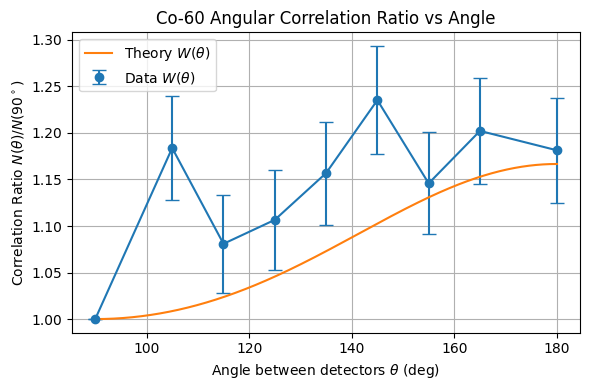

In [26]:
norm_angle = 90.0

angles = df.index.to_numpy(dtype=float)
fine_angles = np.linspace(angles[0], angles[-1], 10**3)

corr_ratio = df["W"].to_numpy(dtype=float)
corr_ratio_unc = df["W_unc"].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    angles, corr_ratio, yerr=corr_ratio_unc,
    capsize=5, fmt="o", color="C0", label=r"Data $W(\theta)$",
)

ax.plot(
    angles, corr_ratio, color="C0"
)

ax.plot(
    fine_angles, co60_angular_correlation(fine_angles),
    color="C1", label=r"Theory $W(\theta)$",
)

ax.set_xlabel(r"Angle between detectors $\theta$ (deg)")
ax.set_ylabel(r"Correlation Ratio $N(\theta)/N(90^\circ)$")
ax.set_title("Co-60 Angular Correlation Ratio vs Angle")
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()

# Single trigger sanity-check 

In [27]:
CH1_TRIGGER_RUN_CONFIGS_19May2026_BINNED = establish_binning(CH1_TRIGGER_RUN_CONFIGS_19May2026)

CH2_TRIGGER_RUN_CONFIGS_19May2026_BINNED = establish_binning(CH2_TRIGGER_RUN_CONFIGS_19May2026)

In [28]:
CH1_TRIGGER_RUN_CONFIGS_19May2026_CALIB = copy_calibration(
    CH1_TRIGGER_RUN_CONFIGS_19May2026_BINNED, 
    RUN_CONFIGS_COINC_19May2026_CALIB)

CH2_TRIGGER_RUN_CONFIGS_19May2026_CALIB = copy_calibration(
    CH2_TRIGGER_RUN_CONFIGS_19May2026_BINNED, 
    RUN_CONFIGS_COINC_19May2026_CALIB)

In [29]:
ch1_df = collect_single_trigger_counts(
    CH1_TRIGGER_RUN_CONFIGS_19May2026_CALIB,
    1,
    co60_tols)

ch2_df = collect_single_trigger_counts(
    CH2_TRIGGER_RUN_CONFIGS_19May2026_CALIB,
    2,
    co60_tols)

display(ch1_df)
display(ch2_df)

,N,N_unc
angle,,
90.0,3423,58.506410
105.0,3608,60.066630
115.0,3439,58.642988
125.0,3303,57.471732
135.0,3225,56.789083
145.0,3247,56.982453
155.0,3283,57.297469
165.0,3297,57.419509
180.0,3281,57.280014


,N,N_unc
angle,,
90.0,3293,57.384667
105.0,3375,58.094750
115.0,3296,57.410800
125.0,3078,55.479726
135.0,3252,57.026310
145.0,3175,56.347138
155.0,3432,58.583274
165.0,3365,58.008620
180.0,3147,56.098128


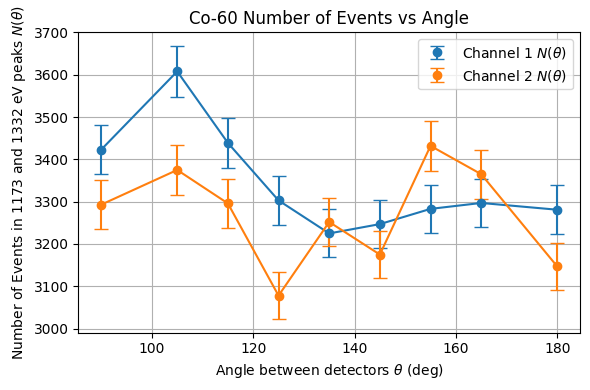

In [30]:
angles = ch1_df.index.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(6, 4))

ch1_n = ch1_df["N"].to_numpy(dtype=float)
ch1_n_unc = ch1_df["N_unc"].to_numpy(dtype=float)

ch2_n = ch2_df["N"].to_numpy(dtype=float)
ch2_n_unc = ch2_df["N_unc"].to_numpy(dtype=float)

ax.errorbar(
    angles, ch1_n, yerr=ch1_n_unc,
    capsize=5, fmt="o", color="C0", label=r"Channel 1 $N(\theta)$",
)
ax.plot(angles, ch1_n, color="C0")

ax.errorbar(
    angles, ch2_n, yerr=ch2_n_unc,
    capsize=5, fmt="o", color="C1", label=r"Channel 2 $N(\theta)$",
)
ax.plot(angles, ch2_n, color="C1")

ax.set_xlabel(r"Angle between detectors $\theta$ (deg)")
ax.set_ylabel(r"Number of Events in 1173 and 1332 eV peaks $N(\theta)$")
ax.set_title("Co-60 Number of Events vs Angle")
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()